In [64]:
%pip install numpy matplotlib scipy tensorly scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [65]:
import numpy as np
import matplotlib.pyplot as plt
import tensorly as tl

from scipy.special import jn
from sklearn.utils.extmath import randomized_svd
from tensorly import unfold

tl.set_backend("numpy")

print("Libraries loaded.")

Libraries loaded.


In [66]:
# Coordinates and radial wave numbers use W0 units.
W0 = 1.0
N_lg = 1024
N = N_lg
WINDOW_SIZE = 8.0 * W0
dx = WINDOW_SIZE / (N - 1)
RANK_LIST = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
RANK = 80  # Rank used in this experiment
RI_DIM = 2
N_LIST = np.array([0])  # Keep l=0
KR_LIST = np.linspace(5.0, 20.0, 16)
N_MODES = len(N_LIST)
KR_MODES = len(KR_LIST)
COMPRESSION_DIM = (RI_DIM, N_MODES, KR_MODES, N_lg, N_lg)
# The existing FFT pipeline omits the singleton l axis.
BEAM_INDICES = np.arange(KR_MODES)  # All 16 radial patterns, l=0
BEAM_KR_LIST = KR_LIST[BEAM_INDICES]
RANDOM_SEED = 42
SHIFT_MAX = 0.5 * W0  # Random x/y shifts within +/-0.5 W0
# Integer-pixel shifts isolate compression error from subpixel interpolation.
rng = np.random.default_rng(RANDOM_SEED)
max_shift_pixels = int(np.floor(SHIFT_MAX / dx))
SHIFT_PIXEL_LIST = rng.integers(-max_shift_pixels, max_shift_pixels + 1,
                                size=(len(BEAM_INDICES), 2))
SHIFT_LIST = SHIFT_PIXEL_LIST * dx
SHIFT_X_LIST = SHIFT_LIST[:, 0]
SHIFT_Y_LIST = SHIFT_LIST[:, 1]
# Extend the original unit-amplitude, pi/3 phase-step weights to all beams.
WEIGHT_LIST = np.exp(1j * np.arange(len(BEAM_INDICES)) * np.pi / 3)
# Preserve aperture/window ratio to suppress FFT edge effects.
APERTURE_RADIUS = 0.3 * WINDOW_SIZE
assert len(BEAM_INDICES) == len(SHIFT_LIST) == len(WEIGHT_LIST)
print(f"N = {N}, dx = {dx:.6f} [W0]")
for i, (kr, (sx, sy)) in enumerate(zip(BEAM_KR_LIST, SHIFT_LIST)):
    print(f"Beam {i+1}: l=0, kr={kr:.2f} [1/W0], x={sx:.4f}, y={sy:.4f} [W0]")

N = 1024, dx = 0.007820 [W0]
Beam 1: l=0, kr=5.00 [1/W0], x=-0.4066, y=0.2737 [W0]
Beam 2: l=0, kr=6.00 [1/W0], x=0.1564, y=-0.0626 [W0]
Beam 3: l=0, kr=7.00 [1/W0], x=-0.0704, y=0.3597 [W0]
Beam 4: l=0, kr=8.00 [1/W0], x=-0.4145, y=0.1955 [W0]
Beam 5: l=0, kr=9.00 [1/W0], x=-0.2972, y=-0.4066 [W0]
Beam 6: l=0, kr=10.00 [1/W0], x=0.0235, y=0.4692 [W0]
Beam 7: l=0, kr=11.00 [1/W0], x=0.2346, y=0.2581 [W0]
Beam 8: l=0, kr=12.00 [1/W0], x=0.2190, y=0.2815 [W0]
Beam 9: l=0, kr=13.00 [1/W0], x=0.0156, y=-0.3675 [W0]
Beam 10: l=0, kr=14.00 [1/W0], x=0.3363, y=-0.0469 [W0]
Beam 11: l=0, kr=15.00 [1/W0], x=0.0000, y=-0.1251 [W0]
Beam 12: l=0, kr=16.00 [1/W0], x=-0.3128, y=0.4223 [W0]
Beam 13: l=0, kr=17.00 [1/W0], x=0.2815, y=0.1408 [W0]
Beam 14: l=0, kr=18.00 [1/W0], x=-0.0938, y=0.3206 [W0]
Beam 15: l=0, kr=19.00 [1/W0], x=0.0469, y=-0.0547 [W0]
Beam 16: l=0, kr=20.00 [1/W0], x=-0.0469, y=-0.2737 [W0]


In [67]:
# ============================================================
# Coordinates
# ============================================================

x = np.linspace(-4 * W0, 4 * W0, N)
y = np.linspace(-4 * W0, 4 * W0, N)
X, Y = np.meshgrid(x, y)

# ============================================================
# Bessel beam
# ============================================================

def bessel_beam_normalized(n, kr, r, phi):
    # Raw field, without additional power normalization.
    amplitude_term = jn(n, kr * r)
    phase_term = np.exp(1j * n * phi)
    return (amplitude_term * phase_term).astype(np.complex64)


def make_bessel(
    kr,
    x0=0.0,
    y0=0.0,
):
    """
    中心座標(x0, y0)にBessel beamを生成する。
    """

    R = np.sqrt(
        (X - x0)**2
        + (Y - y0)**2
    )

    phi = np.arctan2(Y - y0, X - x0)
    beam = bessel_beam_normalized(0, kr, R, phi)

    # 有限計算領域用のsuper-Gaussian aperture
    aperture = np.exp(
        -(
            R / APERTURE_RADIUS
        )**8
    )

    return (
        beam * aperture
    ).astype(np.complex64)


# ============================================================
# Error
# ============================================================

def relative_error(
    reference,
    result,
):
    return (
        np.linalg.norm(
            reference - result
        )
        /
        np.linalg.norm(reference)
    )


print("Functions ready.")

Functions ready.


In [68]:
# ============================================================
# Ground truth
# ============================================================

field_theory = np.zeros(
    (N, N),
    dtype=np.complex64,
)

theory_beams = []

for (
    kr,
    (shift_x, shift_y),
    weight,
) in zip(
    BEAM_KR_LIST,
    SHIFT_LIST,
    WEIGHT_LIST,
):

    beam = make_bessel(
        kr,
        shift_x,
        shift_y,
    )

    theory_beams.append(
        weight * beam
    )

    field_theory += (
        weight * beam
    )


print(
    "Theory field shape:",
    field_theory.shape,
)

Theory field shape: (1024, 1024)


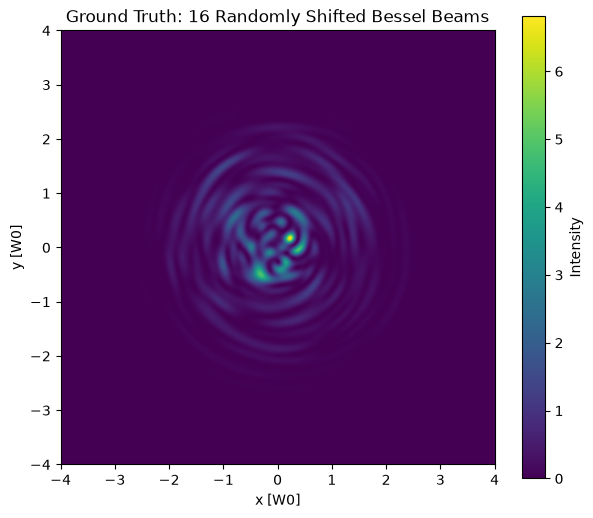

In [69]:
I_theory = np.abs(
    field_theory
) ** 2

extent_w0 = [
    x.min(),
    x.max(),
    y.min(),
    y.max(),
]

plt.figure(figsize=(7, 6))

plt.imshow(
    I_theory,
    extent=extent_w0,
    origin="lower",
)

plt.xlabel("x [W0]")
plt.ylabel("y [W0]")
plt.title(f"Ground Truth: {len(BEAM_INDICES)} Randomly Shifted Bessel Beams")

plt.colorbar(
    label="Intensity"
)

plt.show()

In [70]:
from time import perf_counter
preparation_times = {}
_prep_start = perf_counter()
# ============================================================
# Centered Bessel tensor
# ============================================================

bessel_centered = np.stack(
    [
        make_bessel(
            kr,
            0.0,
            0.0,
        )
        for kr in KR_LIST
    ],
    axis=0,
)

# [beam, y, x]

preparation_times['centered_beams'] = perf_counter() - _prep_start

print(
    "Centered Bessel tensor:",
    bessel_centered.shape,
)

Centered Bessel tensor: (16, 1024, 1024)


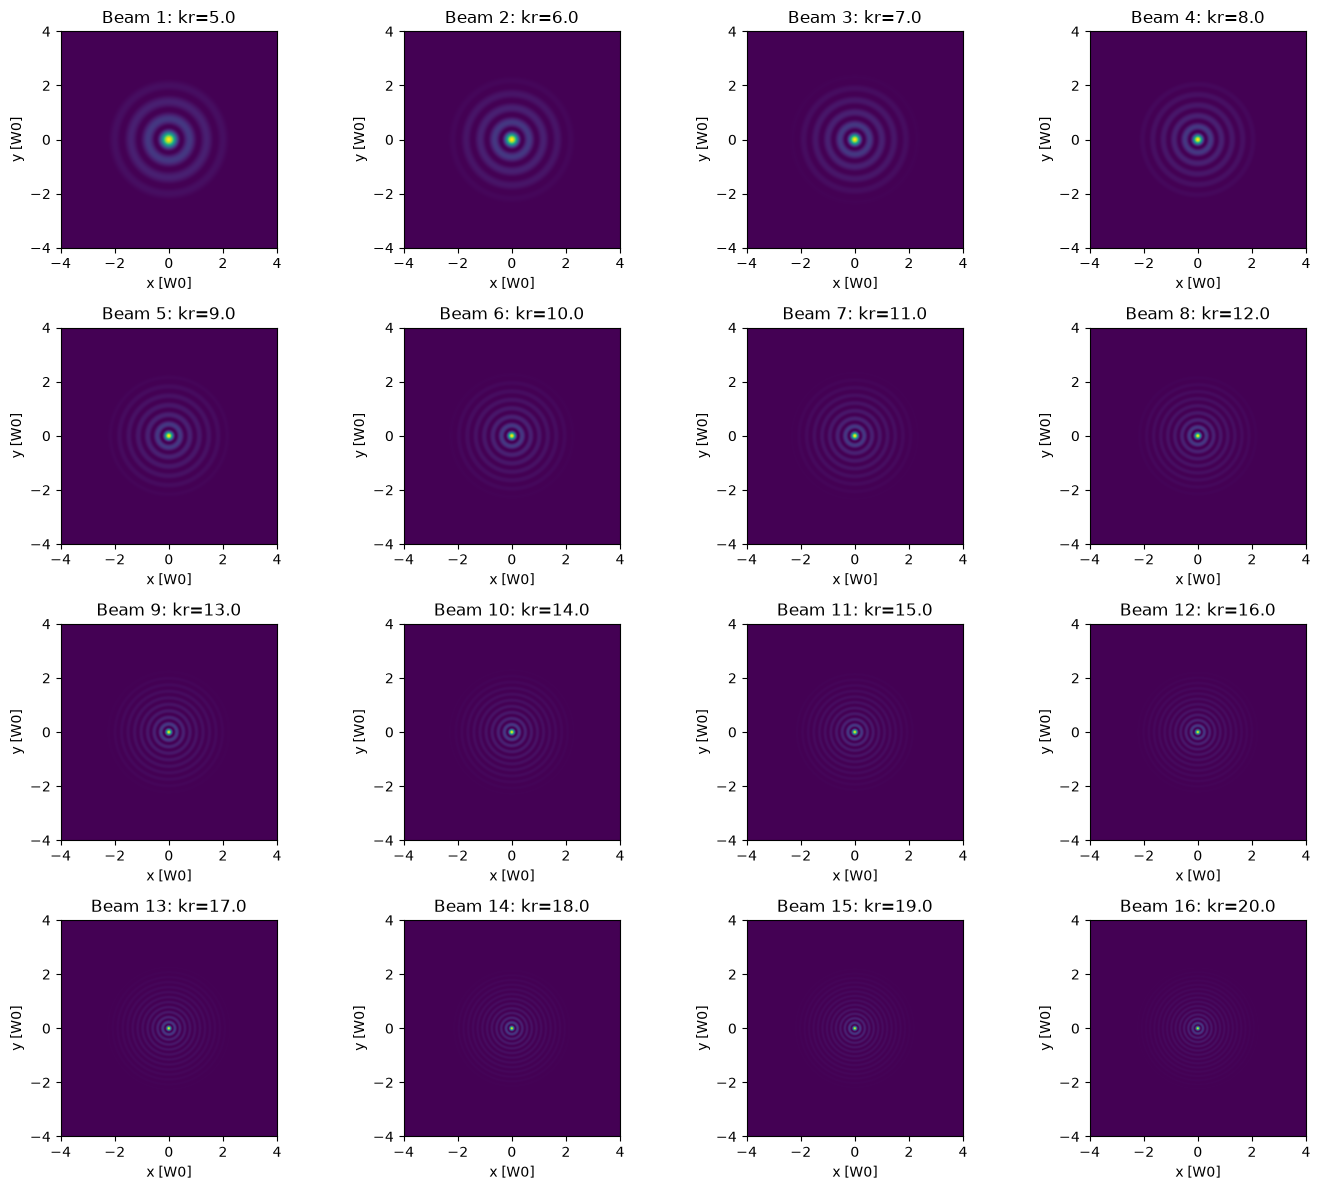

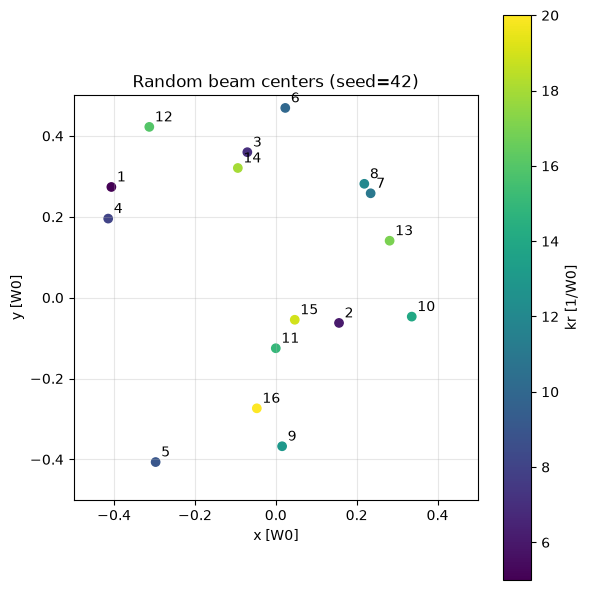

In [71]:
fig, axes = plt.subplots(4, 4, figsize=(14, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(np.abs(bessel_centered[BEAM_INDICES[i]]) ** 2,
              extent=extent_w0, origin="lower")
    ax.set_title(f"Beam {i+1}: kr={BEAM_KR_LIST[i]:.1f}")
    ax.set_xlabel("x [W0]")
    ax.set_ylabel("y [W0]")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(SHIFT_X_LIST, SHIFT_Y_LIST, c=BEAM_KR_LIST, cmap="viridis")
for i, (sx, sy) in enumerate(SHIFT_LIST):
    plt.annotate(str(i + 1), (sx, sy), xytext=(4, 4), textcoords="offset points")
plt.xlim(-SHIFT_MAX, SHIFT_MAX)
plt.ylim(-SHIFT_MAX, SHIFT_MAX)
plt.gca().set_aspect("equal")
plt.xlabel("x [W0]")
plt.ylabel("y [W0]")
plt.title(f"Random beam centers (seed={RANDOM_SEED})")
plt.colorbar(label="kr [1/W0]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [72]:
from time import perf_counter
_prep_start = perf_counter()
# ============================================================
# FFT
# ============================================================

bessel_fft = np.fft.fft2(
    bessel_centered,
    axes=(-2, -1),
    norm="ortho",
)

# [beam, ky, kx]

fft_tensor = np.stack(
    [
        bessel_fft.real,
        bessel_fft.imag,
    ],
    axis=0,
).astype(np.float32)

# [Re/Im, beam, ky, kx]

preparation_times['fft_tensor'] = perf_counter() - _prep_start

print(
    "Bessel FFT:",
    bessel_fft.shape,
)

print(
    "FFT tensor:",
    fft_tensor.shape,
)

Bessel FFT: (16, 1024, 1024)
FFT tensor: (2, 16, 1024, 1024)


In [73]:
from time import perf_counter
_prep_start = perf_counter()
# ============================================================
# Tucker / HOSVD
# ============================================================

mode_ky = 2
mode_kx = 3


# ------------------------------------------------------------
# ky factor
# ------------------------------------------------------------

unfolded_ky = unfold(
    fft_tensor,
    mode_ky,
)

factor_ky, _, _ = randomized_svd(
    unfolded_ky,
    n_components=RANK,
    n_iter=5,
    random_state=42,
)

factor_ky = factor_ky.astype(
    np.float32
)

del unfolded_ky


# ------------------------------------------------------------
# kx factor
# ------------------------------------------------------------

unfolded_kx = unfold(
    fft_tensor,
    mode_kx,
)

factor_kx, _, _ = randomized_svd(
    unfolded_kx,
    n_components=RANK,
    n_iter=5,
    random_state=42,
)

factor_kx = factor_kx.astype(
    np.float32
)

del unfolded_kx


# ------------------------------------------------------------
# Core
# ------------------------------------------------------------

core = tl.tenalg.multi_mode_dot(
    fft_tensor,
    [
        factor_ky.T,
        factor_kx.T,
    ],
    modes=[
        mode_ky,
        mode_kx,
    ],
)

core = np.asarray(
    core,
    dtype=np.float32,
)


preparation_times['hosvd'] = perf_counter() - _prep_start

print(
    "Original:",
    fft_tensor.shape,
)

print(
    "Core:",
    core.shape,
)

print(
    "factor ky:",
    factor_ky.shape,
)

print(
    "factor kx:",
    factor_kx.shape,
)

Original: (2, 16, 1024, 1024)
Core: (2, 16, 80, 80)
factor ky: (1024, 80)
factor kx: (1024, 80)


In [74]:
from time import perf_counter
_prep_start = perf_counter()
# ============================================================
# Real/Imag core -> Complex core
# ============================================================

core_complex = (
    core[0]
    + 1j * core[1]
)

# [beam, rank, rank]

preparation_times['complex_core'] = perf_counter() - _prep_start

print(
    "Complex core:",
    core_complex.shape,
)

Complex core: (16, 80, 80)


In [75]:
from time import perf_counter
_prep_start = perf_counter()
# ============================================================
# Fourier coordinates
# ============================================================

kx = (
    2.0
    * np.pi
    * np.fft.fftfreq(
        N,
        d=dx,
    )
)

ky = (
    2.0
    * np.pi
    * np.fft.fftfreq(
        N,
        d=dx,
    )
)

preparation_times['frequency_grid'] = perf_counter() - _prep_start

print(
    "kx:",
    kx.shape,
)

print(
    "ky:",
    ky.shape,
)

kx: (1024,)
ky: (1024,)


In [76]:
# ============================================================
# Proposed method
#
# Core-space shift + Core-space addition
# ============================================================

core_total = np.zeros(
    (RANK, RANK),
    dtype=np.complex64,
)

subspace_errors = []


for i, (
    shift_x,
    shift_y,
) in enumerate(
    SHIFT_LIST
):

    # --------------------------------------------------------
    # Fourier shift phase
    # --------------------------------------------------------

    phase_x = np.exp(
        -1j
        * kx
        * shift_x
    )

    phase_y = np.exp(
        -1j
        * ky
        * shift_y
    )


    # --------------------------------------------------------
    # Reduced shift operators
    #
    # R = U^H D U
    #
    # factorは実数なので .T でOK
    # --------------------------------------------------------

    R_x = (
        factor_kx.T
        @ (
            phase_x[:, None]
            * factor_kx
        )
    )

    R_y = (
        factor_ky.T
        @ (
            phase_y[:, None]
            * factor_ky
        )
    )


    # --------------------------------------------------------
    # Shift the core
    #
    # D_y U_y G U_x^T D_x
    #
    # ≈
    #
    # U_y R_y G R_x^T U_x^T
    # --------------------------------------------------------

    core_shifted = (
        R_y
        @ core_complex[BEAM_INDICES[i]]
        @ R_x.T
    )


    # --------------------------------------------------------
    # Weight + Core addition
    # --------------------------------------------------------

    core_total += (
        WEIGHT_LIST[i]
        * core_shifted
    )


    # --------------------------------------------------------
    # Subspace error
    #
    # D U ≈ U R ?
    # --------------------------------------------------------

    shifted_Ux = (
        phase_x[:, None]
        * factor_kx
    )

    approximated_Ux = (
        factor_kx
        @ R_x
    )

    error_x = (
        np.linalg.norm(
            shifted_Ux
            - approximated_Ux
        )
        /
        np.linalg.norm(
            shifted_Ux
        )
    )


    shifted_Uy = (
        phase_y[:, None]
        * factor_ky
    )

    approximated_Uy = (
        factor_ky
        @ R_y
    )

    error_y = (
        np.linalg.norm(
            shifted_Uy
            - approximated_Uy
        )
        /
        np.linalg.norm(
            shifted_Uy
        )
    )


    subspace_errors.append(
        (
            error_x,
            error_y,
        )
    )


    print(
        f"Beam {i+1}"
    )

    print(
        f"  shift x = "
        f"{shift_x:.4f}, shift y = {shift_y:.4f} [W0]"
    )

    print(
        f"  subspace error x = "
        f"{error_x:.6e}"
    )

    print(
        f"  subspace error y = "
        f"{error_y:.6e}"
    )

Beam 1
  shift x = -0.4066, shift y = 0.2737 [W0]
  subspace error x = 4.178100e-01
  subspace error y = 5.362867e-01
Beam 2
  shift x = 0.1564, shift y = -0.0626 [W0]
  subspace error x = 3.703410e-01
  subspace error y = 4.944523e-01
Beam 3
  shift x = -0.0704, shift y = 0.3597 [W0]
  subspace error x = 3.733387e-01
  subspace error y = 5.448996e-01
Beam 4
  shift x = -0.4145, shift y = 0.1955 [W0]
  subspace error x = 4.228248e-01
  subspace error y = 5.200668e-01
Beam 5
  shift x = -0.2972, shift y = -0.4066 [W0]
  subspace error x = 3.999669e-01
  subspace error y = 5.519769e-01
Beam 6
  shift x = 0.0235, shift y = 0.4692 [W0]
  subspace error x = 3.477492e-01
  subspace error y = 5.574038e-01
Beam 7
  shift x = 0.2346, shift y = 0.2581 [W0]
  subspace error x = 3.908808e-01
  subspace error y = 5.332429e-01
Beam 8
  shift x = 0.2190, shift y = 0.2815 [W0]
  subspace error x = 3.786547e-01
  subspace error y = 5.368481e-01
Beam 9
  shift x = 0.0156, shift y = -0.3675 [W0]
  subspa

In [77]:
# ============================================================
# Reconstruct ONLY ONCE
# ============================================================

fft_proposed = (
    factor_ky
    @ core_total
    @ factor_kx.T
)

field_proposed = np.fft.ifft2(
    fft_proposed,
    norm="ortho",
)

print(
    "Proposed field:",
    field_proposed.shape,
)

Proposed field: (1024, 1024)


In [78]:
# ============================================================
# Full Fourier reference
# ============================================================

fft_full = np.zeros(
    (N, N),
    dtype=np.complex64,
)

for i, (
    shift_x,
    shift_y,
) in enumerate(
    SHIFT_LIST
):

    phase = (
        np.exp(
            -1j
            * ky[:, None]
            * shift_y
        )
        *
        np.exp(
            -1j
            * kx[None, :]
            * shift_x
        )
    )

    fft_full += (
        WEIGHT_LIST[i]
        * bessel_fft[BEAM_INDICES[i]]
        * phase
    )


field_fourier_full = np.fft.ifft2(
    fft_full,
    norm="ortho",
)

print(
    "Full Fourier field:",
    field_fourier_full.shape,
)

Full Fourier field: (1024, 1024)


In [79]:
# ============================================================
# Error evaluation
# ============================================================

error_theory_fourier = relative_error(
    field_theory,
    field_fourier_full,
)

error_theory_proposed = relative_error(
    field_theory,
    field_proposed,
)

error_fourier_proposed = relative_error(
    field_fourier_full,
    field_proposed,
)


print(
    "Theory vs Full Fourier"
)

print(
    f"  {error_theory_fourier:.6e}"
)

print()


print(
    "Theory vs Proposed"
)

print(
    f"  {error_theory_proposed:.6e}"
)

print()


print(
    "Full Fourier vs Proposed"
)

print(
    f"  {error_fourier_proposed:.6e}"
)

Theory vs Full Fourier
  2.509397e-07

Theory vs Proposed
  7.492935e-04

Full Fourier vs Proposed
  7.492920e-04


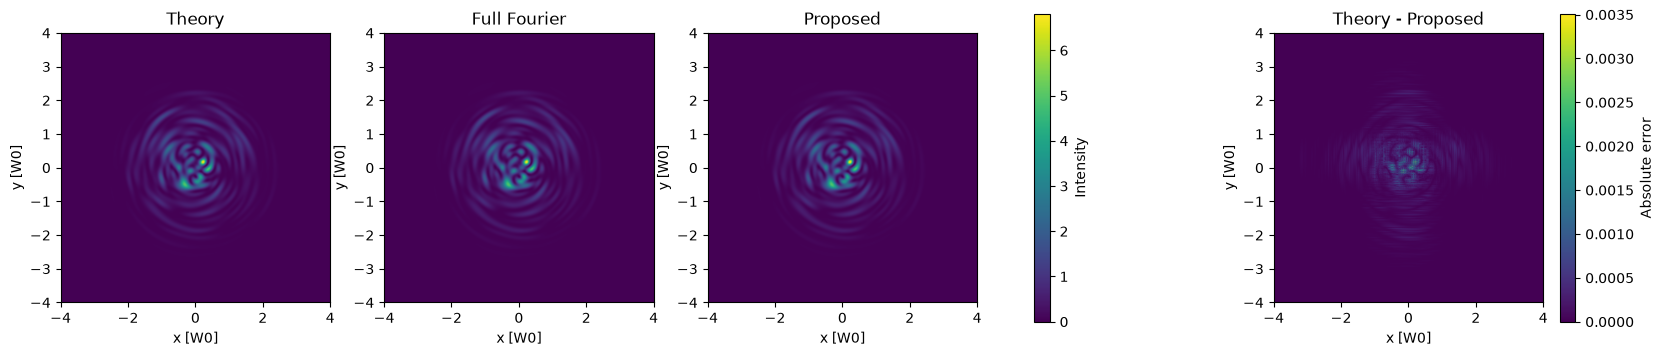

In [80]:
# ============================================================
# Intensity
# ============================================================

I_theory = (
    np.abs(
        field_theory
    ) ** 2
)

I_fourier = (
    np.abs(
        field_fourier_full
    ) ** 2
)

I_proposed = (
    np.abs(
        field_proposed
    ) ** 2
)


I_error = np.abs(
    I_theory
    - I_proposed
)


# 同じスケールで表示
vmax = max(
    I_theory.max(),
    I_proposed.max(),
)


fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5),
)


im0 = axes[0].imshow(
    I_theory,
    extent=extent_w0,
    origin="lower",
    vmin=0,
    vmax=vmax,
)

axes[0].set_title(
    "Theory"
)


im1 = axes[1].imshow(
    I_fourier,
    extent=extent_w0,
    origin="lower",
    vmin=0,
    vmax=vmax,
)

axes[1].set_title(
    "Full Fourier"
)


im2 = axes[2].imshow(
    I_proposed,
    extent=extent_w0,
    origin="lower",
    vmin=0,
    vmax=vmax,
)

axes[2].set_title(
    "Proposed"
)


im3 = axes[3].imshow(
    I_error,
    extent=extent_w0,
    origin="lower",
)

axes[3].set_title(
    "Theory - Proposed"
)


for ax in axes:

    ax.set_xlabel(
        "x [W0]"
    )

    ax.set_ylabel(
        "y [W0]"
    )


plt.colorbar(
    im2,
    ax=axes[:3],
    shrink=0.8,
    label="Intensity",
)

plt.colorbar(
    im3,
    ax=axes[3],
    shrink=0.8,
    label="Absolute error",
)

plt.show()

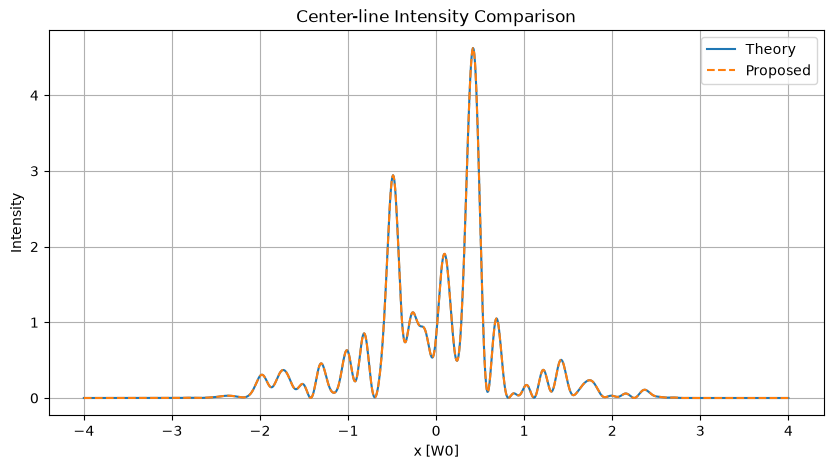

In [81]:
# ============================================================
# Center line
# ============================================================

center_y = N // 2

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    x,
    I_theory[
        center_y,
        :
    ],
    label="Theory",
)

plt.plot(
    x,
    I_proposed[
        center_y,
        :
    ],
    "--",
    label="Proposed",
)

plt.xlabel(
    "x [W0]"
)

plt.ylabel(
    "Intensity"
)

plt.title(
    "Center-line Intensity Comparison"
)

plt.grid()

plt.legend()

plt.show()

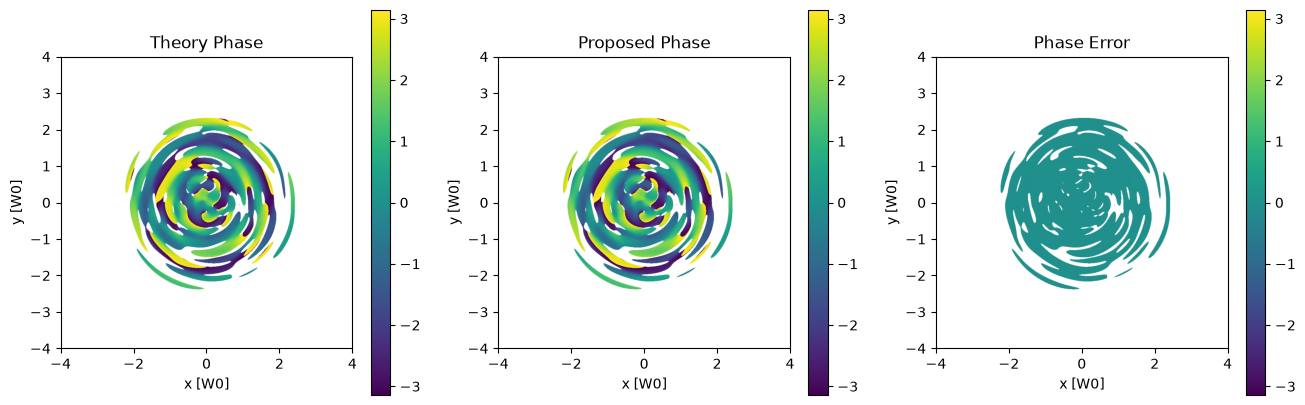

In [82]:
# ============================================================
# Phase
# ============================================================

phase_theory = np.angle(
    field_theory
)

phase_proposed = np.angle(
    field_proposed
)

phase_error = np.angle(
    np.exp(
        1j
        * (
            phase_proposed
            - phase_theory
        )
    )
)


# intensity mask
mask = (
    I_theory
    <
    0.01
    * I_theory.max()
)


phase_theory_masked = np.ma.array(
    phase_theory,
    mask=mask,
)

phase_proposed_masked = np.ma.array(
    phase_proposed,
    mask=mask,
)

phase_error_masked = np.ma.array(
    phase_error,
    mask=mask,
)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
)


im0 = axes[0].imshow(
    phase_theory_masked,
    extent=extent_w0,
    origin="lower",
    vmin=-np.pi,
    vmax=np.pi,
)

axes[0].set_title(
    "Theory Phase"
)


im1 = axes[1].imshow(
    phase_proposed_masked,
    extent=extent_w0,
    origin="lower",
    vmin=-np.pi,
    vmax=np.pi,
)

axes[1].set_title(
    "Proposed Phase"
)


im2 = axes[2].imshow(
    phase_error_masked,
    extent=extent_w0,
    origin="lower",
    vmin=-np.pi,
    vmax=np.pi,
)

axes[2].set_title(
    "Phase Error"
)


for ax in axes:

    ax.set_xlabel(
        "x [W0]"
    )

    ax.set_ylabel(
        "y [W0]"
    )


plt.colorbar(
    im0,
    ax=axes[0],
)

plt.colorbar(
    im1,
    ax=axes[1],
)

plt.colorbar(
    im2,
    ax=axes[2],
)

plt.show()

In [83]:
# Timing comparison: run the preceding cells first.
# Shared X/Y grids are excluded from both methods.
# Preparation covers all 16 basis beams; direct evaluation uses all 16 beams.
# Plotting, printing and error diagnostics are outside timed regions.
from time import perf_counter

BENCHMARK_REPEATS = 5
BENCHMARK_WARMUPS = 1


def benchmark_theory():
    field = np.zeros((N, N), dtype=np.complex64)
    for index, (sx, sy), weight in zip(BEAM_INDICES, SHIFT_LIST, WEIGHT_LIST):
        field += weight * make_bessel(KR_LIST[index], sx, sy)
    return field


def benchmark_proposed():
    # Include phase generation and reduced shift operators on every call.
    total = np.zeros((RANK, RANK), dtype=np.complex64)
    for index, (sx, sy), weight in zip(BEAM_INDICES, SHIFT_LIST, WEIGHT_LIST):
        px = np.exp(-1j * kx * sx)
        py = np.exp(-1j * ky * sy)
        rx = factor_kx.T @ (px[:, None] * factor_kx)
        ry = factor_ky.T @ (py[:, None] * factor_ky)
        total += weight * (ry @ core_complex[index] @ rx.T)
    spectrum = factor_ky @ total @ factor_kx.T
    return np.fft.ifft2(spectrum, norm="ortho")


assert BENCHMARK_REPEATS >= 1 and BENCHMARK_WARMUPS >= 0
assert len(BEAM_INDICES) == len(SHIFT_LIST) == len(WEIGHT_LIST)
assert factor_kx.shape == factor_ky.shape == (N, RANK)
assert core_complex.shape == (len(KR_LIST), RANK, RANK)
if 'preparation_times' not in globals():
    raise RuntimeError('Run all cells from the centered Bessel tensor onward first.')

In [84]:
# Warm up both methods, then alternate execution order to reduce order bias.
for _ in range(BENCHMARK_WARMUPS):
    benchmark_theory()
    benchmark_proposed()

benchmark_samples = {'Theory': [], 'Proposed online': []}
benchmark_functions = {
    'Theory': benchmark_theory,
    'Proposed online': benchmark_proposed,
}
benchmark_fields = {}
for repeat in range(BENCHMARK_REPEATS):
    order = list(benchmark_functions)
    if repeat % 2:
        order.reverse()
    for name in order:
        start = perf_counter()
        result = benchmark_functions[name]()
        elapsed = perf_counter() - start
        benchmark_samples[name].append(elapsed)
        benchmark_fields[name] = result
        del result

# Correctness is checked outside the timing interval.
benchmark_error = relative_error(
    benchmark_fields['Theory'], benchmark_fields['Proposed online']
)
np.testing.assert_allclose(benchmark_fields['Theory'], field_theory, rtol=1e-5, atol=1e-6)
np.testing.assert_allclose(benchmark_fields['Proposed online'], field_proposed, rtol=1e-5, atol=1e-6)
print(f'Relative field error (theory vs proposed): {benchmark_error:.6e}')

Relative field error (theory vs proposed): 7.492935e-04


In [85]:
theory_seconds = float(np.median(benchmark_samples['Theory']))
proposed_seconds = float(np.median(benchmark_samples['Proposed online']))
preparation_seconds = sum(preparation_times.values())

print(f'N={N}, rank={RANK}, selected beams={len(BEAM_INDICES)}, basis beams={len(KR_LIST)}')
print(f'Warmups={BENCHMARK_WARMUPS}, repeats={BENCHMARK_REPEATS}')
print('\nOnline timings (seconds):')
print(f'{"Method":<22} {"Median":>12} {"Min":>12} {"Max":>12}')
for name, samples in benchmark_samples.items():
    print(f'{name:<22} {np.median(samples):12.6f} {min(samples):12.6f} {max(samples):12.6f}')
print(f'\nOnline speed ratio (theory / proposed): {theory_seconds / proposed_seconds:.3f}x')
print('A ratio above 1 means the proposed method is faster.')
print('\nPreparation timings (single measurements from preceding cells):')
for name, seconds in preparation_times.items():
    print(f'  {name:<22} {seconds:.6f} s')
print(f'  Total                  {preparation_seconds:.6f} s')
print(f'Estimated first-use proposed time (preparation + online median): '
      f'{preparation_seconds + proposed_seconds:.6f} s')

if theory_seconds > proposed_seconds:
    break_even_calls = int(np.floor(preparation_seconds / (theory_seconds - proposed_seconds))) + 1
    print(f'Estimated calls to amortize preparation: {break_even_calls}')
else:
    print('No preparation break-even: proposed online time is not shorter in this run.')
print('Reuse estimates assume the same grid, wave-number library and rank.')
print('The direct baseline uses the existing make_bessel implementation (l=0).')

N=1024, rank=80, selected beams=16, basis beams=16
Warmups=1, repeats=5

Online timings (seconds):
Method                       Median          Min          Max
Theory                    11.844394    11.728826    11.893119
Proposed online            0.082366     0.080547     0.092518

Online speed ratio (theory / proposed): 143.802x
A ratio above 1 means the proposed method is faster.

Preparation timings (single measurements from preceding cells):
  centered_beams         11.611127 s
  fft_tensor             0.630479 s
  hosvd                  1.815061 s
  complex_core           0.000858 s
  frequency_grid         0.000261 s
  Total                  14.057786 s
Estimated first-use proposed time (preparation + online median): 14.140153 s
Estimated calls to amortize preparation: 2
Reuse estimates assume the same grid, wave-number library and rank.
The direct baseline uses the existing make_bessel implementation (l=0).


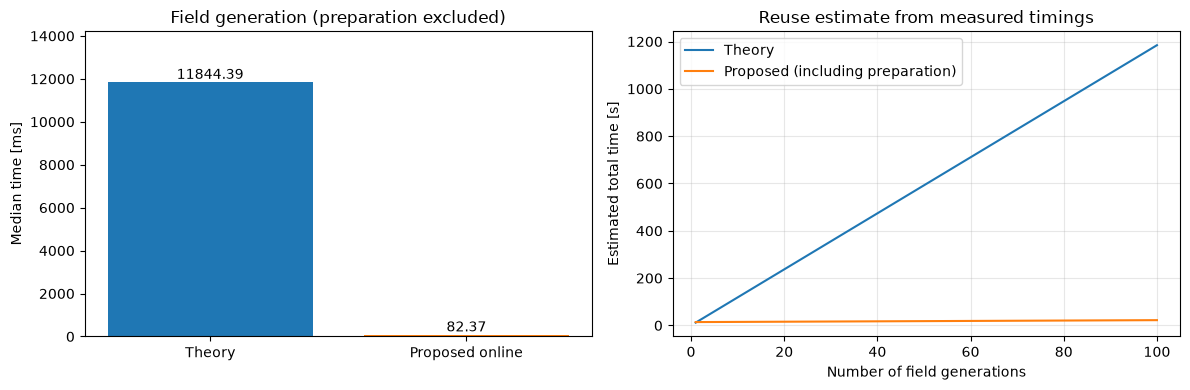

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = list(benchmark_samples)
medians_ms = [1000 * np.median(benchmark_samples[name]) for name in labels]
bars = axes[0].bar(labels, medians_ms, color=['tab:blue', 'tab:orange'])
axes[0].bar_label(bars, fmt='%.2f')
axes[0].set_ylabel('Median time [ms]')
axes[0].set_title('Field generation (preparation excluded)')
axes[0].set_ylim(0, max(medians_ms) * 1.2)

call_counts = np.arange(1, 101)
axes[1].plot(call_counts, call_counts * theory_seconds, label='Theory')
axes[1].plot(call_counts, preparation_seconds + call_counts * proposed_seconds,
             label='Proposed (including preparation)')
axes[1].set_xlabel('Number of field generations')
axes[1].set_ylabel('Estimated total time [s]')
axes[1].set_title('Reuse estimate from measured timings')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()